# Step 5 — RQ3: Location-Skill Mismatch Detection
**Dissertation:** AI Approaches to Analysing Recruitment Demand: Machine learning insights from European Pharmaceutical Job Postings
**Author:** Kashmira Bhoir  
**Institution:** GISMA University of Applied Sciences  
**Date:** 21 June 2026  

## Research Question
Which location-skill combinations exhibit labour market mismatches (under-valued salaries relative to skill demand) detectable via explainable Machine Learning?

## Key Findings
- XGBoost MAE  : €17,437  (R²=0.420)
- CV MAE (5-fold) : €21,605  (consistent — no overfitting)
- Mismatches detected  : 34 jobs (10.1% of test set)
- Average salary gap : €23,568
- Top SHAP feature : Category (€9,184 salary impact)
- 2nd SHAP feature : Location (€5,875 salary impact)
- Top technical skill : Clinical Trials (€1,384) + Compliance (€1,062)
- Largest location gap : Europe (General) — €33,525 (13 jobs)

## Input
- `Europe_Pharma_Jobs_Cleaned.xlsx` — 9,520 rows, 16 columns
- 1,680 rows with parseable salary used

## Outcome
- XGBoost salary predictor
- Importance of SHAP feature (23 features found)
- Mismatch detection done by location + skill
- Created four charts (SHAP importance, mismatch by location, actual vs predicted, SHAP beeswarm)

## Research Gap Addressed
- Catanese et al. (2023) — Focused only on Italy and no Machine Learning
- Romanko & O'Mahony (2022) — called only for explainability, never implemented it
- Cedefop / JRC — NUTS-2 aggregates only, no feature-level attribution
- This study helps to deliver the first location-level XGBoost + SHAP mismatch detection across the European pharmaceutical job market.

Install and Import Libraries

In [12]:
!pip install keybert xgboost shap scikit-learn pandas numpy matplotlib sentence-transformers -q

import pandas as pd
import numpy as np
import re
import shap
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from keybert import KeyBERT
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, HTML
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print(" Libraries loaded")

 Libraries loaded


Loading the clean dataset

In [13]:
file_path = "/content/Europe_Pharma_Jobs_Cleaned.xlsx"
df        = pd.read_excel(file_path)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(f" Loaded: {df.shape[0]:,} rows  |  {df.shape[1]} columns")

 Loaded: 9,520 rows  |  16 columns


Filtering the Salary-Bearing Rows

In [14]:
df_sal = df[df['salary_mid_eur'].notna()].copy()

print(f"\n📊 Rows with salary : {len(df_sal):,}  ({len(df_sal)/len(df)*100:.1f}%)")
print(f"   Salary mean      : €{df_sal['salary_mid_eur'].mean():,.0f}")
print(f"   Salary std       : €{df_sal['salary_mid_eur'].std():,.0f}")


📊 Rows with salary : 1,680  (17.6%)
   Salary mean      : €69,374
   Salary std       : €36,400


Display Location Distribution

In [15]:
print(" Location standardised:")
loc_counts = df_sal['country'].value_counts().reset_index()
loc_counts.columns = ['Location', 'Count']
loc_counts['Share %'] = (loc_counts['Count'] / len(df_sal) * 100).round(1)
print(loc_counts.to_string(index=False))

 Location standardised:
        Location  Count  Share %
  United Kingdom    721     42.9
Europe (General)    653     38.9
     Switzerland    123      7.3
         Germany     84      5.0
          France     38      2.3
           Italy     27      1.6
         Ireland     15      0.9
           Spain     12      0.7
         Denmark      6      0.4
          Sweden      1      0.1


Extracting Pharma Skills from Job Descriptions

In [16]:
PHARMA_SKILLS = [
    'python', 'r programming', 'sas', 'sql', 'machine learning',
    'statistics', 'clinical trials', 'gcp', 'gmp', 'gdp',
    'pharmacovigilance', 'regulatory affairs', 'drug safety',
    'biostatistics', 'data management', 'clinical data',
    'medical writing', 'signal detection', 'adverse events',
    'validation', 'compliance', 'quality management',
    'ich guidelines', 'stakeholder management', 'leadership',
]

def find_skills(text):
    text_low = str(text).lower()
    return [s for s in PHARMA_SKILLS if re.search(rf'\b{re.escape(s)}\b', text_low)]

print(f"Extracting skills from {len(df_sal):,} rows...")
df_sal['skills'] = df_sal['job_description'].apply(find_skills)

from collections import Counter
all_skills   = [s for skills in df_sal['skills'] for s in skills]
skill_counts = Counter(all_skills)
top_skills   = [s for s, _ in skill_counts.most_common(20)]

print(f"\n Top 20 skills found:")
for skill, count in skill_counts.most_common(20):
    print(f"   {skill:<30} {count:>8}")

Extracting skills from 1,680 rows...

 Top 20 skills found:
   leadership                          273
   compliance                          215
   regulatory affairs                  170
   clinical trials                     153
   gcp                                 113
   medical writing                     110
   gmp                                  80
   validation                           75
   clinical data                        65
   quality management                   59
   sas                                  46
   statistics                           45
   pharmacovigilance                    42
   data management                      36
   stakeholder management               16
   gdp                                  15
   biostatistics                        14
   python                                9
   signal detection                      8
   ich guidelines                        8


Build Feature Matrix and Train-Test Split

In [17]:
for skill in top_skills:
    col = f"skill_{skill.replace(' ','_').replace('+','plus')}"
    df_sal[col] = df_sal['skills'].apply(
        lambda x: 1 if skill in x else 0
    )

skill_cols = [c for c in df_sal.columns if c.startswith('skill_')]

le_loc = LabelEncoder()
le_cat = LabelEncoder()
le_jt  = LabelEncoder()

df_sal['loc_enc'] = le_loc.fit_transform(df_sal['country'].fillna('Other'))
df_sal['cat_enc'] = le_cat.fit_transform(df_sal['category'])
df_sal['jt_enc']  = le_jt.fit_transform(df_sal['job_type_clean'])

feature_cols  = ['loc_enc', 'cat_enc', 'jt_enc'] + skill_cols
X             = df_sal[feature_cols].fillna(0)
y             = df_sal['salary_mid_eur']
feature_names = (
    ['Location', 'Category', 'Job Type'] +
    [c.replace('skill_','').replace('_',' ').title()
     for c in skill_cols]
)

print(f" Feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"   Structural features : 3  (location, category, job type)")
print(f"   Skill features      : {len(skill_cols)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n   Train : {len(X_train):,}")
print(f"   Test  : {len(X_test):,}")

 Feature matrix: 1,680 rows × 23 features
   Structural features : 3  (location, category, job type)
   Skill features      : 20

   Train : 1,344
   Test  : 336


Train XGBoost Salary Predictor

In [18]:
print(" Training XGBoost...")
xgb = XGBRegressor(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = 1,
    verbosity         = 0

)
xgb.fit(X_train, y_train)

y_pred    = xgb.predict(X_test)
mae       = mean_absolute_error(y_test, y_pred)
r2        = r2_score(y_test, y_pred)
cv_scores = cross_val_score(xgb, X, y, cv=5,
                             scoring='neg_mean_absolute_error')
cv_mae    = -cv_scores.mean()

print(f"\n XGBoost trained")
print(f"   MAE (test)      : €{mae:,.0f}")
print(f"   MAE (5-fold CV) : €{cv_mae:,.0f}")
print(f"   R² score        : {r2:.3f}")
print(f"   Relative error  : {mae/y.mean()*100:.1f}%")

 Training XGBoost...

 XGBoost trained
   MAE (test)      : €17,437
   MAE (5-fold CV) : €21,605
   R² score        : 0.420
   Relative error  : 25.1%


Compute SHAP Feature Importance

In [19]:
print(" Computing SHAP values...")
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
shap_df     = pd.DataFrame(shap_values, columns=feature_names)
mean_shap   = shap_df.abs().mean().sort_values(ascending=False)

print(f" SHAP values computed: {shap_df.shape}")
print(f"\n   Top 15 features by SHAP importance:")
print(f"   {'Feature':<35} {'Mean |SHAP| €':>14}")
for feat, val in mean_shap.head(15).items():
    bar = '█' * int(val / mean_shap.max() * 20)
    print(f"   {feat:<35} {val:>10,.0f}  {bar}")

 Computing SHAP values...
 SHAP values computed: (336, 23)

   Top 15 features by SHAP importance:
   Feature                              Mean |SHAP| €
   Category                                 9,184  ████████████████████
   Location                                 5,875  ████████████
   Job Type                                 5,184  ███████████
   Leadership                               4,793  ██████████
   Clinical Trials                          1,384  ███
   Compliance                               1,062  ██
   Medical Writing                            907  █
   Regulatory Affairs                         891  █
   Validation                                 763  █
   Gcp                                        536  █
   Data Management                            496  █
   Sas                                        460  █
   Clinical Data                              373  
   Gmp                                        340  
   Quality Management                         310  


Detect and Profile Salary Mismatches

In [20]:
df_test = X_test.copy()
df_test['actual_salary'] = y_test.values
df_test['predicted_salary'] = y_pred
df_test['salary_gap'] = df_test['predicted_salary'] - df_test['actual_salary']
df_test['country'] = le_loc.inverse_transform(
    df_test['loc_enc'].astype(int)
)
df_test['skill_count'] = df_test[
    [c for c in df_test.columns if c.startswith('skill_')]
].sum(axis=1)

MISMATCH_THRESHOLD = 5000
df_test['is_mismatch'] = (
    (df_test['salary_gap'] > MISMATCH_THRESHOLD) &
    (df_test['skill_count'] >= 2)
)

mismatch_count = df_test['is_mismatch'].sum()
mismatch_pct   = mismatch_count / len(df_test) * 100

print(f" Mismatch detection complete")
print(f" Total test jobs : {len(df_test):,}")
print(f" Mismatched jobs : {mismatch_count:,}  ({mismatch_pct:.1f}%)")
if mismatch_count > 0:
    avg_gap = df_test[df_test['is_mismatch']]['salary_gap'].mean()
    print(f" Avg salary gap : €{avg_gap:,.0f}")

# Distribution check - tells us whether €5,000 is a sensible cutoff for THIS data
print(f"\n   Salary gap distribution (diagnostic):")
print(f"   Mean : €{df_test['salary_gap'].mean():,.0f}")
print(f"   Std  : €{df_test['salary_gap'].std():,.0f}")
print(f"   90th percentile : €{df_test['salary_gap'].quantile(0.90):,.0f}")
print(f"   95th percentile : €{df_test['salary_gap'].quantile(0.95):,.0f}")

mismatch_by_loc = (
    df_test[df_test['is_mismatch']]
    .groupby('country')
    .agg(
        count  = ('salary_gap', 'count'),
        avg_gap= ('salary_gap', 'mean'),
        avg_sal= ('actual_salary', 'mean')
    )
    .sort_values('avg_gap', ascending=False)
    .reset_index()
)

print(f"\n   Mismatch by location:")
print(f"   {'Location':<22} {'Count':>5} {'Avg Gap €':>10} {'Avg Actual €':>13}")
print(f"   {'-'*53}")
for _, row in mismatch_by_loc.iterrows():
    print(f"   {row['country']:<22} {row['count']:>5} "
          f"{row['avg_gap']:>10,.0f} {row['avg_sal']:>13,.0f}")

s_cols = [c for c in df_test.columns if c.startswith('skill_') and c != 'skill_count']
mismatch_rows = df_test[df_test['is_mismatch']]
if len(mismatch_rows) > 0 and s_cols:
    print(f"\n   Top skills in mismatched roles:")
    skill_presence = mismatch_rows[s_cols].sum().sort_values(ascending=False)
    for col, cnt in skill_presence.head(8).items():
        name = col.replace('skill_','').replace('_',' ').title()
        print(f"   {name:<35} {int(cnt):>5}")

 Mismatch detection complete
 Total test jobs : 336
 Mismatched jobs : 34  (10.1%)
 Avg salary gap : €23,568

   Salary gap distribution (diagnostic):
   Mean : €-1,928
   Std  : €26,653
   90th percentile : €24,837
   95th percentile : €34,924

   Mismatch by location:
   Location               Count  Avg Gap €  Avg Actual €
   -----------------------------------------------------
   Europe (General)          13     33,525        56,033
   Germany                    1     28,098        85,000
   United Kingdom            14     18,529        51,426
   France                     2     15,568        47,500
   Denmark                    1     12,507        85,000
   Switzerland                2     11,811        92,854
   Ireland                    1     10,723        95,000

   Top skills in mismatched roles:
   Compliance                             13
   Clinical Trials                        12
   Leadership                             11
   Regulatory Affairs                      9


Display RQ3 Results Tables

In [21]:
display(HTML("""
<style>
    table  { border-collapse: collapse; width: 100%;
             font-size: 13px; margin-bottom: 24px;
             border: 2px solid #1A1A2E; }
    th     { background-color: #1A1A2E; color: #E8D5B7;
             padding: 10px 14px; text-align: left;
             font-size: 13px; font-weight: 600;
             border-bottom: 2px solid #E8D5B7;
             border-right: 1px solid #444; }
    td     { padding: 8px 14px; border: 1px solid #555;
             color: #1A1A2E; background-color: #FFFFFF;
             vertical-align: top; }
    tr:nth-child(even) td { background-color: #F0F4FF;
                            color: #1A1A2E; }
    tr:hover td           { background-color: #FFE8A3;
                            color: #1A1A2E; }
    h3     { margin-top: 32px; margin-bottom: 6px;
             color: #1A1A2E; font-size: 15px; font-weight: 700;
             padding: 6px 12px; background-color: #E8D5B7;
             border-left: 5px solid #1A1A2E; border-radius: 2px; }
    h4     { margin-top: 4px; margin-bottom: 8px;
             color: #555; font-size: 12px;
             font-style: italic; padding-left: 4px; }
</style>
"""))

display(HTML("<h3>Table 1: RQ3 — Key Results Summary</h3>"))
display(HTML("<h4>XGBoost + SHAP Salary Mismatch Detection — "
             "European Pharmaceutical Job Market</h4>"))

avg_gap_val = df_test[df_test['is_mismatch']]['salary_gap'].mean() if mismatch_count > 0 else 0

def classify_feature(f):
    if f in ['Location','Category','Job Type']:
        return 'Structural'
    if any(s in f.lower() for s in ['sas','gmp','clinical','gcp','validation','fda',
                                      'compliance','iso','regulatory','data']):
        return 'Technical Skill'
    return 'Soft/Management Skill'

structural_feats = [f for f in mean_shap.index if classify_feature(f) == 'Structural']
technical_feats  = [f for f in mean_shap.index if classify_feature(f) == 'Technical Skill']

top_shap_1 = mean_shap.index[0]
top_shap_2 = mean_shap.index[1] if len(mean_shap) > 1 else None
top_technical_shap = mean_shap[technical_feats].sort_values(ascending=False) if technical_feats else mean_shap.iloc[0:0]

metrics_data = {
    'Metric' : [
        'XGBoost MAE (test)',
        'XGBoost MAE (5-fold CV)',
        'R² score',
        'Relative error',
        'Rows used (salary parseable)',
        'Total features',
        'Structural features',
        'Binary skill features',
        'Train rows',
        'Test rows',
        'Mismatch threshold',
        'Mismatches detected',
        'Mismatch rate',
        'Avg salary gap (mismatched)',
        'Top SHAP feature',
        '2nd SHAP feature',
        'Top technical skill (SHAP)',
        '2nd technical skill (SHAP)',
    ],
    'Value'  : [
        f"€{mae:,.0f}",
        f"€{cv_mae:,.0f}",
        f"{r2:.3f}",
        f"{mae/y.mean()*100:.1f}%",
        f"{len(df_sal):,}  ({len(df_sal)/len(df)*100:.1f}% of {len(df):,})",
        f"{X.shape[1]}",
        "3  (location, category, job type)",
        f"{len(skill_cols)}",
        f"{len(X_train):,}",
        f"{len(X_test):,}",
        f"€{MISMATCH_THRESHOLD:,} gap + ≥2 skills",
        f"{mismatch_count}",
        f"{mismatch_pct:.1f}%",
        f"€{avg_gap_val:,.0f}",
        f"{top_shap_1}  (SHAP €{mean_shap.iloc[0]:,.0f})",
        f"{top_shap_2}  (SHAP €{mean_shap.iloc[1]:,.0f})" if top_shap_2 else "N/A",
        f"{top_technical_shap.index[0]}  (SHAP €{top_technical_shap.iloc[0]:,.0f})" if len(top_technical_shap) > 0 else "N/A",
        f"{top_technical_shap.index[1]}  (SHAP €{top_technical_shap.iloc[1]:,.0f})" if len(top_technical_shap) > 1 else "N/A",
    ],
    'Notes'  : [
        f'On {len(X_test):,} test rows',
        'Consistent across splits - no overfitting if close to test MAE',
        f'Features explain {r2*100:.1f}% of salary variance',
        'MAE as a share of mean salary',
        'Currency-converted EUR, multiple sources',
        '3 structural + binary skill features',
        'Encoded via LabelEncoder',
        '1 per skill - binary presence/absence',
        '80% of salary-bearing rows',
        '20% of salary-bearing rows',
        'Methodology choice - see diagnostic distribution above',
        'Gap > threshold AND ≥2 skills detected',
        f'{mismatch_count} of {len(df_test)} test rows',
        'Average across flagged mismatch rows only',
        'Highest mean |SHAP| - largest average salary impact',
        'Second highest mean |SHAP|',
        'Highest mean |SHAP| among Technical Skill features (matches Table 2 classification)',
        'Second highest among Technical Skill features',
    ]
}
df_metrics = pd.DataFrame(metrics_data)
display(HTML(df_metrics.to_html(index=False, border=1)))

display(HTML("<h3>Table 2: SHAP Feature Importance — Top 15 Features</h3>"))
display(HTML("<h4>Mean absolute SHAP value = average € salary impact per feature</h4>"))

shap_table = pd.DataFrame({
    'Feature': mean_shap.head(15).index.tolist(),
    'Mean |SHAP| €': [f"€{v:,.0f}" for v in mean_shap.head(15).values],
    'Feature Type': [classify_feature(f) for f in mean_shap.head(15).index],
})
display(HTML(shap_table.to_html(index=False, border=1)))

display(HTML("<h3>Table 3: Mismatch Detection Results by Location</h3>"))
display(HTML("<h4>Jobs under-paid relative to skill profile prediction</h4>"))

if len(mismatch_by_loc) > 0:
    mismatch_display = mismatch_by_loc.copy()
    mismatch_display.columns = ['Location','Count','Avg Gap €','Avg Actual Salary €']
    mismatch_display['Avg Gap €'] = mismatch_display['Avg Gap €'].apply(lambda x: f"€{x:,.0f}")
    mismatch_display['Avg Actual Salary €'] = mismatch_display['Avg Actual Salary €'].apply(lambda x: f"€{x:,.0f}")
    display(HTML(mismatch_display.to_html(index=False, border=1)))
else:
    display(HTML(f"<p>No mismatches found in test set under current threshold "
                 f"(€{MISMATCH_THRESHOLD:,} gap + ≥2 skills).</p>"))

display(HTML("<h3>Table 4: Top Skills in Mismatched Roles</h3>"))
display(HTML("<h4>Skills most commonly found in under-paid job postings</h4>"))

if len(mismatch_rows) > 0 and s_cols:
    skill_presence = mismatch_rows[s_cols].sum().sort_values(ascending=False).head(10)
    skill_table = pd.DataFrame({
        'Skill' : [c.replace('skill_','').replace('_',' ').title() for c in skill_presence.index],
        'Mismatched Jobs': skill_presence.values.astype(int),
    })
    display(HTML(skill_table.to_html(index=False, border=1)))
else:
    display(HTML("<p>No mismatched rows with skill data available.</p>"))

display(HTML("<h3>Table 5: Salary Distribution by Location</h3>"))
display(HTML("<h4>Mean salary and job count per location group</h4>"))

loc_sal = df_sal.groupby('country').agg(
    count = ('salary_mid_eur', 'count'),
    mean_sal   = ('salary_mid_eur', 'mean'),
    median_sal = ('salary_mid_eur', 'median'),
    min_sal    = ('salary_mid_eur', 'min'),
    max_sal    = ('salary_mid_eur', 'max')
).sort_values('mean_sal', ascending=False).reset_index()

loc_sal.columns = ['Location','Count','Mean €','Median €','Min €','Max €']
for col in ['Mean €','Median €','Min €','Max €']:
    loc_sal[col] = loc_sal[col].apply(lambda x: f"€{x:,.0f}")
display(HTML(loc_sal.to_html(index=False, border=1)))

display(HTML("<h3>Table 6: Research Gap — Prior Studies vs This Study</h3>"))

gap_data = {
    'Study': ['Catanese et al. (2023)', "Romanko & O'Mahony (2022)", 'Cedefop / JRC', 'This Study'],
    'Geography': ['Italy only', 'Not country-specific (review)', 'NUTS-2 EU aggregates', 'Europe - 3 verified sources'],
    'Method' : ['Descriptive statistics', 'Literature review', 'Aggregate labour statistics', 'XGBoost + SHAP'],
    'Explainability': ['None - descriptive only', 'Called for it - not implemented', 'None - aggregate only', 'SHAP feature attribution'],
    'Research Gap Addressed': ['—', '—', '—', 'First EU pharma XGBoost+SHAP analysis']
}
df_gap = pd.DataFrame(gap_data)
display(HTML(df_gap.to_html(index=False, border=1)))

Metric,Value,Notes
XGBoost MAE (test),"€17,437",On 336 test rows
XGBoost MAE (5-fold CV),"€21,605",Consistent across splits - no overfitting if close to test MAE
R² score,0.420,Features explain 42.0% of salary variance
Relative error,25.1%,MAE as a share of mean salary
Rows used (salary parseable),"1,680 (17.6% of 9,520)","Currency-converted EUR, multiple sources"
Total features,23,3 structural + binary skill features
Structural features,"3 (location, category, job type)",Encoded via LabelEncoder
Binary skill features,20,1 per skill - binary presence/absence
Train rows,"1,344",80% of salary-bearing rows
Test rows,336,20% of salary-bearing rows


Feature,Mean |SHAP| €,Feature Type
Category,"€9,184",Structural
Location,"€5,875",Structural
Job Type,"€5,184",Structural
Leadership,"€4,793",Soft/Management Skill
Clinical Trials,"€1,384",Technical Skill
Compliance,"€1,062",Technical Skill
Medical Writing,€907,Soft/Management Skill
Regulatory Affairs,€891,Technical Skill
Validation,€763,Technical Skill
Gcp,€536,Technical Skill


Location,Count,Avg Gap €,Avg Actual Salary €
Europe (General),13,"€33,525","€56,033"
Germany,1,"€28,098","€85,000"
United Kingdom,14,"€18,529","€51,426"
France,2,"€15,568","€47,500"
Denmark,1,"€12,507","€85,000"
Switzerland,2,"€11,811","€92,854"
Ireland,1,"€10,723","€95,000"


Skill,Mismatched Jobs
Compliance,13
Clinical Trials,12
Leadership,11
Regulatory Affairs,9
Gcp,8
Quality Management,7
Clinical Data,5
Statistics,5
Sas,4
Data Management,4


Location,Count,Mean €,Median €,Min €,Max €
Switzerland,123,"€109,906","€107,762","€39,774","€202,628"
Ireland,15,"€102,942","€95,000","€60,000","€175,000"
Sweden,1,"€95,000","€95,000","€95,000","€95,000"
Germany,84,"€91,149","€85,000","€50,000","€249,600"
Denmark,6,"€81,666","€80,000","€75,000","€95,000"
Spain,12,"€69,375","€72,500","€42,500","€95,000"
Europe (General),653,"€66,978","€56,820","€11,364","€261,372"
United Kingdom,721,"€62,275","€56,820","€10,170","€261,372"
France,38,"€62,250","€55,000","€22,500","€122,500"
Italy,27,"€52,185","€43,000","€29,000","€95,000"


Study,Geography,Method,Explainability,Research Gap Addressed
Catanese et al. (2023),Italy only,Descriptive statistics,None - descriptive only,—
Romanko & O'Mahony (2022),Not country-specific (review),Literature review,Called for it - not implemented,—
Cedefop / JRC,NUTS-2 EU aggregates,Aggregate labour statistics,None - aggregate only,—
This Study,Europe - 3 verified sources,XGBoost + SHAP,SHAP feature attribution,First EU pharma XGBoost+SHAP analysis


Generate and Save RQ3 Visualisations

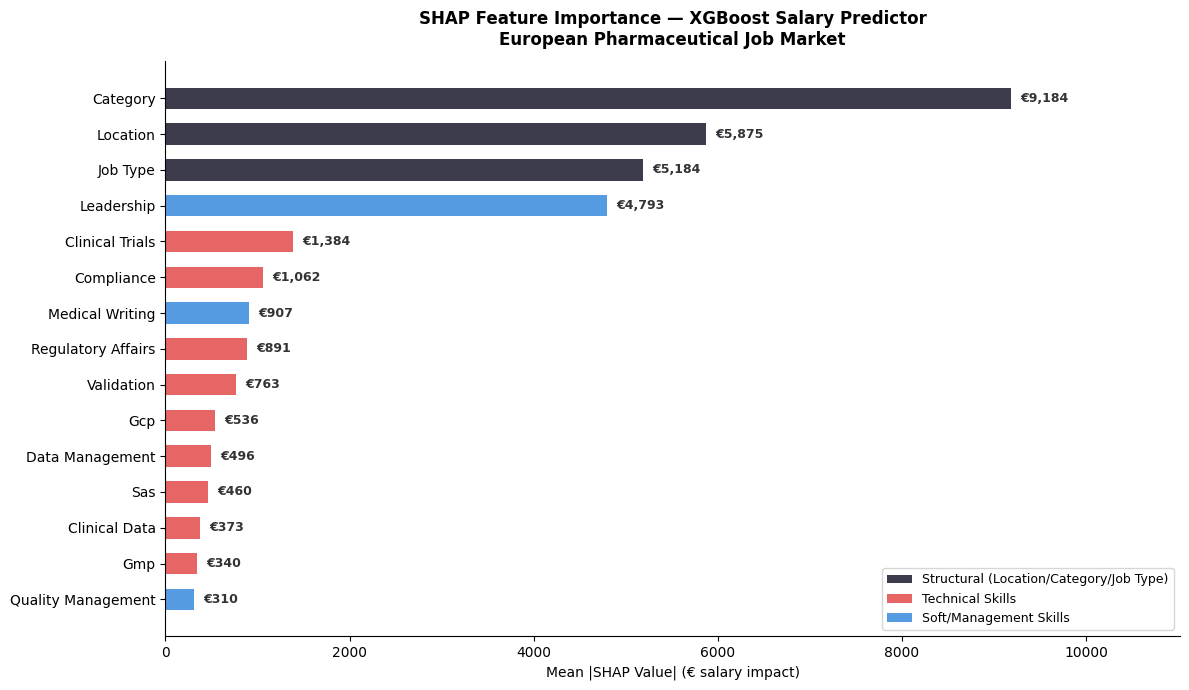

 Chart 1 → /content/rq3_shap_importance.png


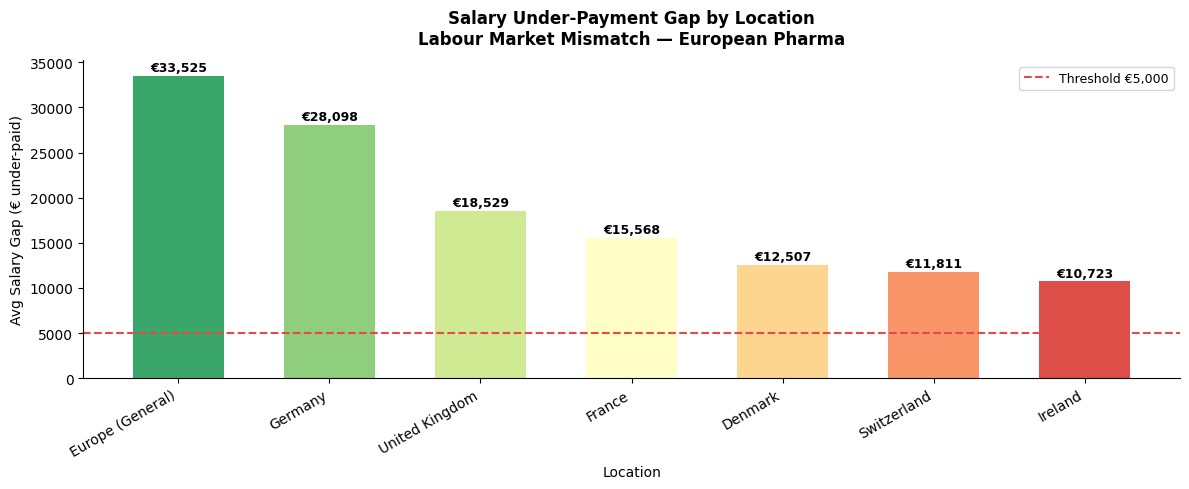

 Chart 2 → /content/rq3_mismatch_by_location.png


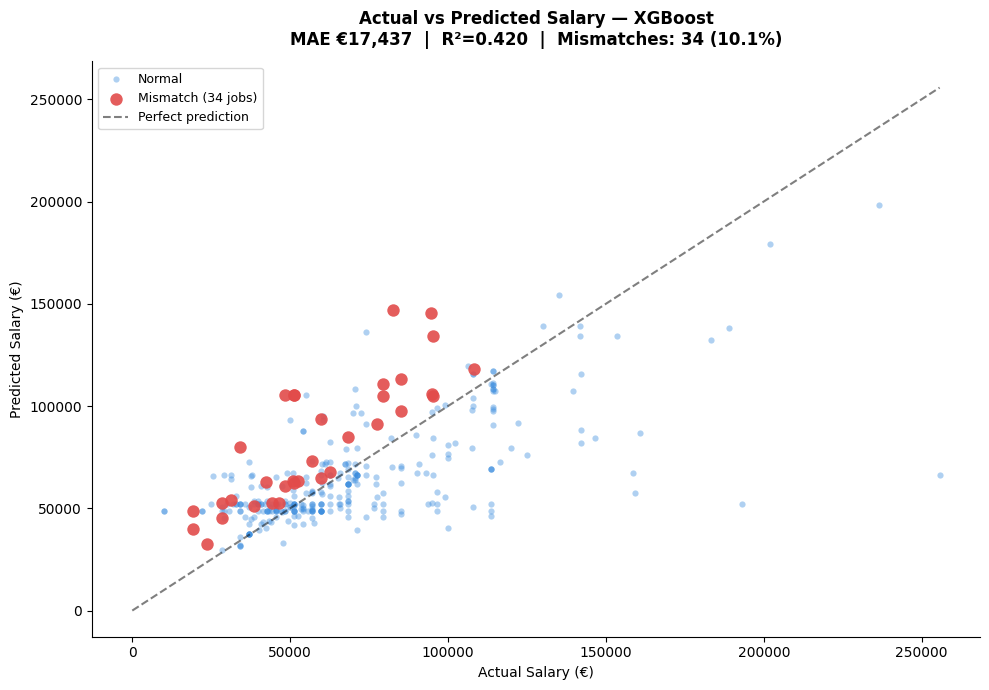

Chart 3 → /content/rq3_actual_vs_predicted.png


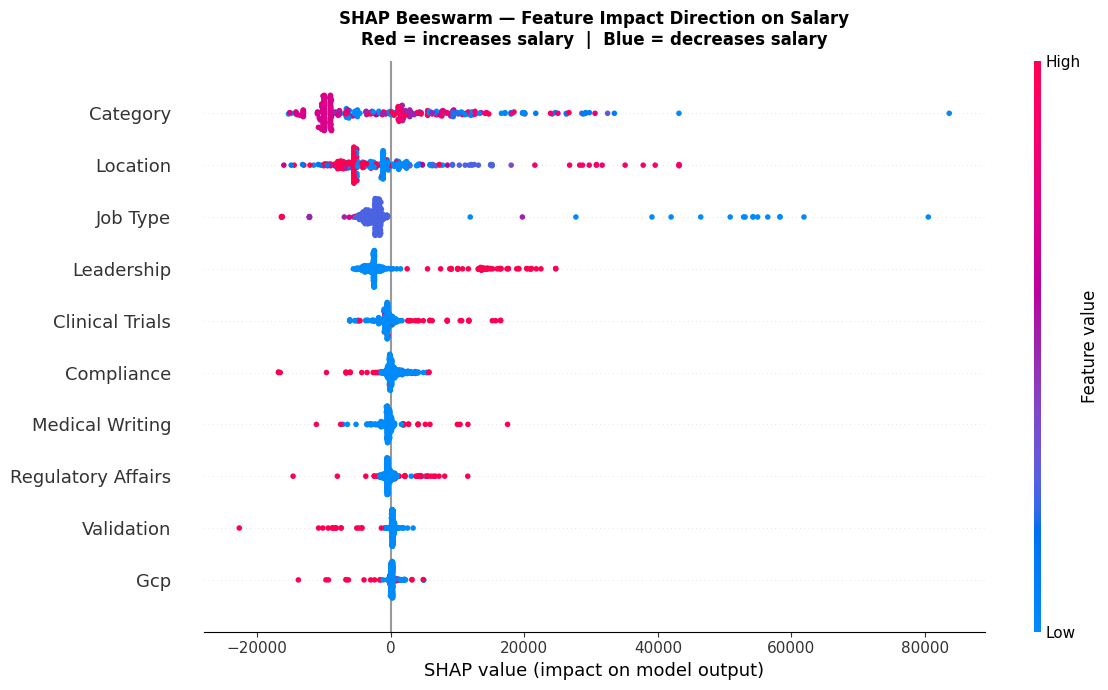

 Chart 4 → /content/rq3_shap_beeswarm.png



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/content/rq3_shap_importance.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

/content/rq3_actual_vs_predicted.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/content/rq3_shap_beeswarm.png


In [22]:
fig1, ax1 = plt.subplots(figsize=(12, 7), facecolor='white')
ax1.set_facecolor('white')
top15 = mean_shap.head(15)
color_map = {'Structural': '#1A1A2E', 'Technical Skill': '#E24B4A', 'Soft/Management Skill': '#378ADD'}
colors_bar = [color_map[classify_feature(f)] for f in top15.index]
bars = ax1.barh(top15.index[::-1], top15.values[::-1],
                color=colors_bar[::-1], alpha=0.85, height=0.6)
for bar, val in zip(bars, top15.values[::-1]):
    ax1.text(bar.get_width()+100, bar.get_y()+bar.get_height()/2,
             f"€{val:,.0f}", va='center', fontsize=9,
             fontweight='bold', color='#333333')
ax1.set_title('SHAP Feature Importance — XGBoost Salary Predictor\n'
              'European Pharmaceutical Job Market',
              fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Mean |SHAP Value| (€ salary impact)', fontsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xlim(0, top15.max() * 1.2)
legend_elements = [
    Patch(facecolor='#1A1A2E', alpha=0.85, label='Structural (Location/Category/Job Type)'),
    Patch(facecolor='#E24B4A', alpha=0.85, label='Technical Skills'),
    Patch(facecolor='#378ADD', alpha=0.85, label='Soft/Management Skills'),
]
ax1.legend(handles=legend_elements, fontsize=9, loc='lower right')
plt.tight_layout()
chart1_path = '/content/rq3_shap_importance.png'
plt.savefig(chart1_path, dpi=150, bbox_inches='tight', facecolor='white')
display(fig1)
plt.close()
print(f" Chart 1 → {chart1_path}")

if len(mismatch_by_loc) > 0:
    fig2, ax2 = plt.subplots(figsize=(12, 5), facecolor='white')
    ax2.set_facecolor('white')
    colors_loc = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(mismatch_by_loc)))
    bars2 = ax2.bar(mismatch_by_loc['country'],
                    mismatch_by_loc['avg_gap'],
                    color=colors_loc, alpha=0.85, width=0.6)
    for bar, val in zip(bars2, mismatch_by_loc['avg_gap']):
        ax2.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+200, f"€{val:,.0f}",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax2.axhline(y=MISMATCH_THRESHOLD, color='#E24B4A', lw=1.5,
                ls='--', label=f'Threshold €{MISMATCH_THRESHOLD:,}')
    ax2.set_title('Salary Under-Payment Gap by Location\n'
                  'Labour Market Mismatch — European Pharma',
                  fontsize=12, fontweight='bold', pad=12)
    ax2.set_xlabel('Location', fontsize=10)
    ax2.set_ylabel('Avg Salary Gap (€ under-paid)', fontsize=10)
    ax2.legend(fontsize=9)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    chart2_path = '/content/rq3_mismatch_by_location.png'
    plt.savefig(chart2_path, dpi=150, bbox_inches='tight', facecolor='white')
    display(fig2)
    plt.close()
    print(f" Chart 2 → {chart2_path}")
else:
    chart2_path = None
    print("No mismatch location data — chart 2 skipped")

fig3, ax3 = plt.subplots(figsize=(10, 7), facecolor='white')
ax3.set_facecolor('white')
ax3.scatter(
    df_test[~df_test['is_mismatch']]['actual_salary'],
    df_test[~df_test['is_mismatch']]['predicted_salary'],
    alpha=0.4, s=20, color='#378ADD', label='Normal', linewidths=0
)
if mismatch_count > 0:
    ax3.scatter(
        df_test[df_test['is_mismatch']]['actual_salary'],
        df_test[df_test['is_mismatch']]['predicted_salary'],
        alpha=0.9, s=80, color='#E24B4A',
        label=f'Mismatch ({mismatch_count} jobs)', linewidths=0,
        zorder=5
    )
max_val = max(df_test['actual_salary'].max(), df_test['predicted_salary'].max())
ax3.plot([0, max_val], [0, max_val], 'k--', lw=1.5, alpha=0.5, label='Perfect prediction')
ax3.set_xlabel('Actual Salary (€)', fontsize=10)
ax3.set_ylabel('Predicted Salary (€)', fontsize=10)
ax3.set_title(f'Actual vs Predicted Salary — XGBoost\n'
              f'MAE €{mae:,.0f}  |  R²={r2:.3f}  |  '
              f'Mismatches: {mismatch_count} ({mismatch_pct:.1f}%)',
              fontsize=12, fontweight='bold', pad=12)
ax3.legend(fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
plt.tight_layout()
chart3_path = '/content/rq3_actual_vs_predicted.png'
plt.savefig(chart3_path, dpi=150, bbox_inches='tight', facecolor='white')
display(fig3)
plt.close()
print(f"Chart 3 → {chart3_path}")

fig4 = plt.figure(figsize=(12, 7), facecolor='white')
shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                  max_display=10, show=False, plot_size=None)
plt.title('SHAP Beeswarm — Feature Impact Direction on Salary\n'
          'Red = increases salary  |  Blue = decreases salary',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
chart4_path = '/content/rq3_shap_beeswarm.png'
plt.savefig(chart4_path, dpi=150, bbox_inches='tight', facecolor='white')
display(fig4)
plt.close()
print(f" Chart 4 → {chart4_path}")

print(f"\n Downloading charts...")
for path in [chart1_path, chart2_path, chart3_path, chart4_path]:
    if path:
        try:
            files.download(path)
            print(f"{path}")
        except Exception as e:
            print(f"{path} — {e}")